# Project 5: Adult Income Prediction using Neural Computing Methods

This project implements and compares two neural computing models (Multilayer Perceptron and Support Vector Machine)
for predicting whether an individual's income exceeds $50K/year based on census data.

Project Structure:
- Data loading and preprocessing
- Implementation of MLP using PyTorch
- Implementation of SVM using scikit-learn
- Model training and evaluation
- Performance comparison and visualization
- Subgroup analysis to evaluate fairness across demographic groups

Author: Nixon Ng

Date: 6th May 2025

## 1. Imports Section

In [2]:
# --- Imports ---

# Standard libraries for data manipulation and visualization
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch imports for MLP implementation
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Scikit-learn imports for preprocessing, model implementation, and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.inspection import permutation_importance
import warnings

# Filter warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

## 2. Configuration Section

In [3]:
# --- Configuration ---
"""
This section defines all configuration parameters and constants used throughout the project:
- Directory paths for saving models, figures, data, etc.
- Dataset parameters (column names, categorical/numerical features)
- Best hyperparameters for MLP and SVM models (based on prior experimentation)
- Random seed for reproducibility
"""

BASE_DIR = './INM427-Neural-Computing/nn-ind-project/adult-income-prediction' # Change base directory as needed
MODEL_DIR = os.path.join(BASE_DIR, 'models')
FIGURE_DIR = os.path.join(BASE_DIR, 'figures')
DATA_DIR = os.path.join(BASE_DIR, 'data')
FEATURE_DIR = os.path.join(BASE_DIR, 'features')
REPORT_DIR = os.path.join(BASE_DIR, 'reports')

# Create necessary directories if they don't exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FEATURE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Experiment parameters
RANDOM_STATE = 42  # For reproducibility
TEST_SIZE = 0.3    # 70% training, 30% testing split
N_SPLITS_CV = 5    # Number of cross-validation folds
TOP_N_FEATURES = 20  # Number of top features to analyze

# Dataset column definitions
COLUMN_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education.num',
    'marital.status', 'occupation', 'relationship', 'race', 'sex',
    'capital.gain', 'capital.loss', 'hours.per.week',
    'native.country', 'income'
]

# Feature type categorization
CATEGORICAL_COLS = [
    'workclass', 'education', 'marital.status', 'occupation',
    'relationship', 'race', 'sex', 'native.country'
]
NUMERICAL_COLS = [
    'age', 'fnlwgt', 'education.num', 'capital.gain',
    'capital.loss', 'hours.per.week'
]
TARGET_COL = 'income'  # Target variable

# MLP Hyperparameters (optimized from grid search)
MLP_HIDDEN_SIZES = [128, 64, 32]  # Three hidden layers with decreasing neuron counts
MLP_DROPOUT_RATE = 0.3  # Dropout for regularization
MLP_LEARNING_RATE = 0.0001  # Learning rate for Adam optimizer
MLP_WEIGHT_DECAY = 1e-4  # L2 regularization strength
MLP_EPOCHS = 20  # Number of training epochs
MLP_BATCH_SIZE = 128  # Mini-batch size

# SVM Hyperparameters (optimized from grid search)
SVM_C = 100  # Regularization parameter
SVM_GAMMA = 'auto'  # Kernel coefficient
SVM_KERNEL = 'rbf'  # Radial basis function kernel

# Set random seeds for reproducibility
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

## 3. MLP Model Definition

In [4]:
# --- MLP Model Definition ---

class MLP(nn.Module):
    """
    Multi-Layer Perceptron model for binary classification.
    
    Architecture:
    - Variable number of hidden layers with configurable sizes
    - ReLU activation functions after each hidden layer
    - Dropout regularization to prevent overfitting
    - Single output neuron with sigmoid activation (implied by BCEWithLogitsLoss)
    
    Parameters:
    -----------
    input_size : int
        Number of input features
    hidden_sizes : list of int
        Sizes of hidden layers (e.g., [128, 64, 32] for three hidden layers)
    dropout_rate : float
        Dropout probability (0.0 to 1.0)
    """
    def __init__(self, input_size, hidden_sizes, dropout_rate):
        super(MLP, self).__init__()
        layers = []
        
        # Input layer to first hidden layer
        layers.extend([
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        ])
        
        # Additional hidden layers
        for i in range(len(hidden_sizes) - 1):
            layers.extend([
                nn.Linear(hidden_sizes[i], hidden_sizes[i+1]),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            
        # Final layer (outputting logits)
        layers.append(nn.Linear(hidden_sizes[-1], 1))
        
        # Sequential container for all layers
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        """Forward pass through the network"""
        # Squeeze to remove the last dimension for BCEWithLogitsLoss
        return self.model(x).squeeze()

## 4. Training and Evaluation Functions

In [5]:
# --- Training and Evaluation Functions ---

def mlp_train(model, train_loader, criterion, optimizer, num_epochs=20):
    """
    Trains the MLP model using mini-batch gradient descent.
    
    Parameters:
    -----------
    model : torch.nn.Module
        The MLP model to train
    train_loader : torch.utils.data.DataLoader
        DataLoader containing training data
    criterion : torch.nn.Module
        Loss function (BCEWithLogitsLoss for binary classification)
    optimizer : torch.optim.Optimizer
        Optimizer (Adam with weight decay)
    num_epochs : int, default=20
        Number of training epochs
        
    Returns:
    --------
    train_losses : list
        Training loss for each epoch
    train_accuracies : list
        Training accuracy for each epoch
    total_train_time : float
        Total training time in seconds
    """
    model.train()  # Set model to training mode
    train_losses = []
    train_accuracies = []
    train_start_time = time.time()

    print(f"Starting MLP training for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        running_loss = 0.0
        correct = 0
        total = 0

        # Mini-batch training loop
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # Zero the parameter gradients
            outputs = model(inputs)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass (compute gradients)
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()  # Update weights

            # Track statistics
            running_loss += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()  # Threshold at 0.5
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Calculate epoch statistics
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        epoch_time = time.time() - epoch_start_time
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
             print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}, Time: {epoch_time:.2f}s')

    total_train_time = time.time() - train_start_time
    print(f'Total training time: {total_train_time:.2f} seconds')
    return train_losses, train_accuracies, total_train_time

def evaluate_model(model, test_loader, criterion, model_type='mlp'):
    """
    Evaluates a trained PyTorch model on test data.
    
    Parameters:
    -----------
    model : torch.nn.Module
        The trained model to evaluate
    test_loader : torch.utils.data.DataLoader
        DataLoader containing test data
    criterion : torch.nn.Module
        Loss function used during training
    model_type : str, default='mlp'
        Model type identifier for logging purposes
        
    Returns:
    --------
    results : dict
        Dictionary containing evaluation metrics:
        - accuracy, precision, recall, f1, auc
        - inference_time
        - predictions, probabilities, labels
    """
    model.eval()  # Set model to evaluation mode
    test_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []
    all_preds_binary = []

    # Measure inference time
    inference_start_time = time.time()
    
    # No gradient calculation during evaluation
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track statistics
            test_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(outputs)  # Convert logits to probabilities
            predicted = (probs > 0.5).float()  # Threshold at 0.5
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Store predictions and labels for metric calculation
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_preds_binary.extend(predicted.cpu().numpy())

    inference_time = time.time() - inference_start_time

    # Calculate overall metrics
    test_loss /= total
    test_accuracy = correct / total
    all_labels = np.array(all_labels).astype(int)
    all_preds_binary = np.array(all_preds_binary).astype(int)
    all_probs = np.array(all_probs)

    # Print evaluation results
    print(f'{model_type.upper()} Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')
    print(f'{model_type.upper()} Inference time: {inference_time:.2f} seconds')
    print(f'{model_type.upper()} Average inference time per sample: {inference_time/total*1000:.2f} ms')

    # Calculate classification metrics
    pos_label = 1 if 1 in np.unique(all_labels) else 0  # Handle edge case of all same class
    precision = precision_score(all_labels, all_preds_binary, pos_label=pos_label, zero_division=0)
    recall = recall_score(all_labels, all_preds_binary, pos_label=pos_label, zero_division=0)
    f1 = f1_score(all_labels, all_preds_binary, pos_label=pos_label, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5

    print(f'{model_type.upper()} Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')

    # Package results into dictionary
    results = {
        'accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'inference_time': inference_time,
        'predictions': all_preds_binary,
        'probabilities': all_probs,
        'labels': all_labels
    }
    return results

def svm_evaluate(pipeline, X_test_processed, y_test):
    """
    Evaluates a trained SVM pipeline on test data.
    
    Parameters:
    -----------
    pipeline : sklearn.pipeline.Pipeline
        Trained SVM pipeline including preprocessing steps
    X_test_processed : numpy.ndarray
        Preprocessed test features
    y_test : numpy.ndarray
        Test target values
        
    Returns:
    --------
    results : dict
        Dictionary containing evaluation metrics:
        - accuracy, precision, recall, f1, auc
        - inference_time
        - predictions, probabilities, labels
    """
    # Measure inference time
    inference_start_time = time.time()
    svm_pred = pipeline.predict(X_test_processed)
    svm_prob = pipeline.predict_proba(X_test_processed)[:, 1]  # Probability of positive class
    inference_time = time.time() - inference_start_time

    # Calculate classification metrics
    accuracy = accuracy_score(y_test, svm_pred)
    precision = precision_score(y_test, svm_pred, zero_division=0)
    recall = recall_score(y_test, svm_pred, zero_division=0)
    f1 = f1_score(y_test, svm_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, svm_prob) if len(np.unique(y_test)) > 1 else 0.5

    # Print evaluation results
    print(f"SVM Test Accuracy: {accuracy:.4f}")
    print(f'SVM Inference time: {inference_time:.2f} seconds')
    print(f'SVM Average inference time per sample: {inference_time/len(y_test)*1000:.2f} ms')
    print(f'SVM Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')

    # Package results into dictionary
    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'inference_time': inference_time,
        'predictions': svm_pred,
        'probabilities': svm_prob,
        'labels': y_test
    }
    return results

## 5. Plotting Functions

In [6]:
# --- Plotting Functions ---

def plot_training_curves(losses, accuracies, model_name, save_path):
    """
    Plots training loss and accuracy curves.
    
    Parameters:
    -----------
    losses : list
        List of training losses for each epoch
    accuracies : list
        List of training accuracies for each epoch
    model_name : str
        Name of the model for plot titles
    save_path : str
        Path to save the figure
    """
    plt.figure(figsize=(12, 5))
    
    # Plot training loss
    plt.subplot(1, 2, 1)
    plt.plot(losses)
    plt.title(f'{model_name} Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    # Plot training accuracy
    plt.subplot(1, 2, 2)
    plt.plot(accuracies)
    plt.title(f'{model_name} Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    """
    Plots the confusion matrix for model evaluation.
    
    Parameters:
    -----------
    y_true : array-like
        Ground truth labels
    y_pred : array-like
        Predicted labels
    model_name : str
        Name of the model for plot title
    save_path : str
        Path to save the figure
        
    Returns:
    --------
    int
        Total number of misclassifications
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix ({model_name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
    # Calculate and return total misclassifications (false positives + false negatives)
    return cm[0, 1] + cm[1, 0]

def plot_roc_curve(y_true, y_prob, model_name, save_path):
    """
    Plots the ROC curve for model evaluation.
    
    Parameters:
    -----------
    y_true : array-like
        Ground truth labels
    y_prob : array-like
        Predicted probabilities for the positive class
    model_name : str
        Name of the model for plot title
    save_path : str
        Path to save the figure
        
    Returns:
    --------
    float
        Area Under the ROC Curve (AUC)
    """
    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal reference line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic ({model_name})')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    
    return roc_auc

def plot_feature_importance(importance_df, model_name, save_path, top_n=20):
    """
    Plots feature importance.
    
    Parameters:
    -----------
    importance_df : pandas.DataFrame
        DataFrame containing features and their importance scores
    model_name : str
        Name of the model for plot title
    save_path : str
        Path to save the figure
    top_n : int, default=20
        Number of top features to display
    """
    plt.figure(figsize=(12, 8))
    plt_data = importance_df.head(min(top_n, len(importance_df)))
    sns.barplot(x='Importance', y='Feature', data=plt_data)
    plt.title(f'Top {top_n} Most Important Features ({model_name})')
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

## 6. Subgroup Analysis Functions

In [7]:
# --- Subgroup Analysis Function ---

def analyze_subgroup(data, group_column, true_label_col='true_label', pred_cols=['mlp_pred', 'svm_pred']):
    """
    Analyzes model performance across demographic subgroups.
    
    This function is important for assessing potential bias in model predictions
    across different demographic groups such as gender, race, or age.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        DataFrame containing group information, true labels, and model predictions
    group_column : str
        Column name for the subgroup to analyze (e.g., 'sex', 'race', 'age_group')
    true_label_col : str, default='true_label'
        Column name for the true labels
    pred_cols : list of str, default=['mlp_pred', 'svm_pred']
        Column names for model predictions
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with performance metrics for each subgroup
    """
    groups = data[group_column].unique()
    results = []

    # Calculate metrics for each group
    for group in groups:
        group_data = data[data[group_column] == group].copy()
        group_data = group_data.dropna(subset=[true_label_col])  # Drop rows with NaN true labels
        if group_data.empty:
            continue

        # Store group info and count
        group_result = {'Group': group, 'Count': len(group_data)}
        
        # Calculate accuracy for each model
        for pred_col in pred_cols:
            model_name = pred_col.split('_')[0].upper()
            accuracy = accuracy_score(group_data[true_label_col], group_data[pred_col])
            group_result[f'{model_name}_Accuracy'] = accuracy

        # Calculate model performance difference
        if 'MLP_Accuracy' in group_result and 'SVM_Accuracy' in group_result:
             group_result['Difference'] = group_result['MLP_Accuracy'] - group_result['SVM_Accuracy']

        results.append(group_result)

    # Create and sort results DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Count', ascending=False)
    return results_df

# PyTorch model wrapper for sklearn compatibility
class PyTorchModelWrapper:
    """
    Wrapper for using PyTorch models with scikit-learn's permutation_importance.
    
    This class enables compatibility between PyTorch models and scikit-learn's
    feature importance analysis tools.
    
    Parameters:
    -----------
    model : torch.nn.Module
        PyTorch model to wrap
    """
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        """
        Generate predictions from the PyTorch model.
        
        Parameters:
        -----------
        X : numpy.ndarray
            Input features
            
        Returns:
        --------
        numpy.ndarray
            Binary predictions (0 or 1)
        """
        X_tensor = torch.tensor(X, dtype=torch.float32)
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_tensor)
            return (torch.sigmoid(outputs) > 0.5).float().numpy()

    def score(self, X, y):
        """
        Calculate accuracy score for the model.
        
        Parameters:
        -----------
        X : numpy.ndarray
            Input features
        y : numpy.ndarray
            True labels
            
        Returns:
        --------
        float
            Accuracy score
        """
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)

    # Needed for compatibility with scikit-learn's API
    def fit(self, X, y):
        """Dummy method for scikit-learn API compatibility"""
        return self

## 7. Data Loading and Preprocessing

Loading data from UCI ML Repository...
Dataset loaded with 32561 rows and 15 columns

Target Variable Distribution:
income
0    24720
1     7841
Name: count, dtype: int64
income
0    75.919044
1    24.080956
Name: proportion, dtype: float64


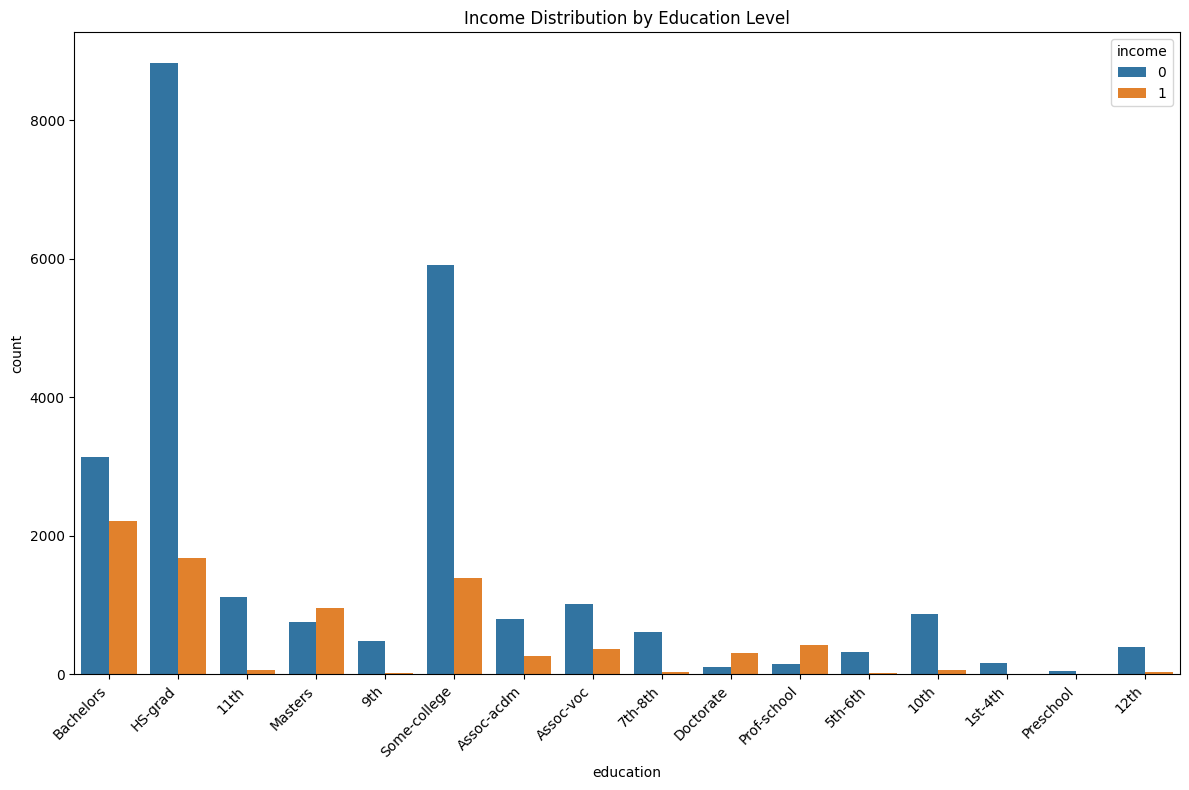

Training set size: 22792 samples
Test set size: 9769 samples
Processed training data shape: (22792, 108)
Processed test data shape: (9769, 108)
Number of features after preprocessing: 108


In [8]:
# --- Data Loading and Preprocessing ---

# Load the UCI Adult Census Income dataset
data_url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

# Try to load from URL, fall back to local cache if needed
try:
    print("Loading data from UCI ML Repository...")
    df = pd.read_csv(data_url, header=None, names=COLUMN_NAMES,
                     na_values=' ?', skipinitialspace=True)
except Exception as e:
    print(f"Error loading data from URL: {e}")
    print("Attempting to load from local cache if available.")
    local_path = os.path.join(DATA_DIR, 'adult.csv')
    if os.path.exists(local_path):
        df = pd.read_csv(local_path, na_values='?', skipinitialspace=True)
    else:
        raise ValueError("Could not load data from URL or local cache.")

# Save a local copy for future use
df.to_csv(os.path.join(DATA_DIR, 'adult.csv'), index=False)
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns")

# --- Data Cleaning & Initial EDA ---

# Map target variable: convert string labels to binary values
df[TARGET_COL] = df[TARGET_COL].map({'<=50K': 0, '>50K': 1})

# Remove rows with missing target values
df.dropna(subset=[TARGET_COL], inplace=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)

# Display class distribution to assess imbalance
print("\nTarget Variable Distribution:")
print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True) * 100)

# Explore relationship between education and income (example of EDA)
plt.figure(figsize=(12, 8))
sns.countplot(x='education', hue=TARGET_COL, data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Income Distribution by Education Level')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_education_income.png'))
plt.show()

# --- Feature Engineering & Preprocessing Pipeline ---

# Define preprocessing steps for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())  # Standardize features
])

# Define preprocessing steps for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encoding
])

# Combine preprocessing steps into a single transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, NUMERICAL_COLS),
        ('cat', categorical_transformer, CATEGORICAL_COLS)
    ],
    remainder='drop'  # Drop columns not specified
)

# --- Data Splitting ---

# Split features and target
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

# Split data into training and testing sets with stratification
# Stratified split preserves the class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Keep original test features for subgroup analysis
X_test_orig = X_test.copy()

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# --- Apply Preprocessing ---

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding for feature importance analysis
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(ohe.get_feature_names_out(CATEGORICAL_COLS))
feature_names = NUMERICAL_COLS + cat_feature_names
input_size = len(feature_names)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")
print(f"Number of features after preprocessing: {input_size}")

# --- Prepare Data for PyTorch ---

# Convert preprocessed numpy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_processed)
X_test_tensor = torch.FloatTensor(X_test_processed)
y_train_tensor = torch.FloatTensor(y_train.values)  # Use .values to ensure numpy array
y_test_tensor = torch.FloatTensor(y_test.values)

# Create TensorDatasets and DataLoaders for batch processing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=MLP_BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=MLP_BATCH_SIZE, shuffle=False)

# # --- Save Processed Data (Optional) ---
# # This allows reusing the processed data without repeating preprocessing steps

# # Convert y_test to numpy for consistent saving
# y_test_np = y_test.to_numpy()
# torch.save(X_test_tensor, os.path.join(FEATURE_DIR, 'X_test_tensor.pt'))
# np.save(os.path.join(FEATURE_DIR, 'y_test.npy'), y_test_np)
# # Save original test features for subgroup analysis
# X_test_orig.to_csv(os.path.join(FEATURE_DIR, 'X_test_orig.csv'), index=False)

## 8. MLP Model Implementation

MLP model architecture:
MLP(
  (model): Sequential(
    (0): Linear(in_features=108, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

=== Training MLP Model ===
Starting MLP training for 20 epochs...
Epoch 1/20, Loss: 0.6304, Accuracy: 0.7470, Time: 1.06s
Epoch 5/20, Loss: 0.3401, Accuracy: 0.8421, Time: 0.91s
Epoch 10/20, Loss: 0.3259, Accuracy: 0.8510, Time: 0.92s
Epoch 15/20, Loss: 0.3175, Accuracy: 0.8521, Time: 1.05s
Epoch 20/20, Loss: 0.3151, Accuracy: 0.8564, Time: 1.45s
Total training time: 19.78 seconds

=== Evaluating MLP Model ===
MLP Test Loss: 0.3054, Test Accuracy: 0.8605
MLP Inference time: 0.18 seconds
MLP Average inference time per sample: 0.0

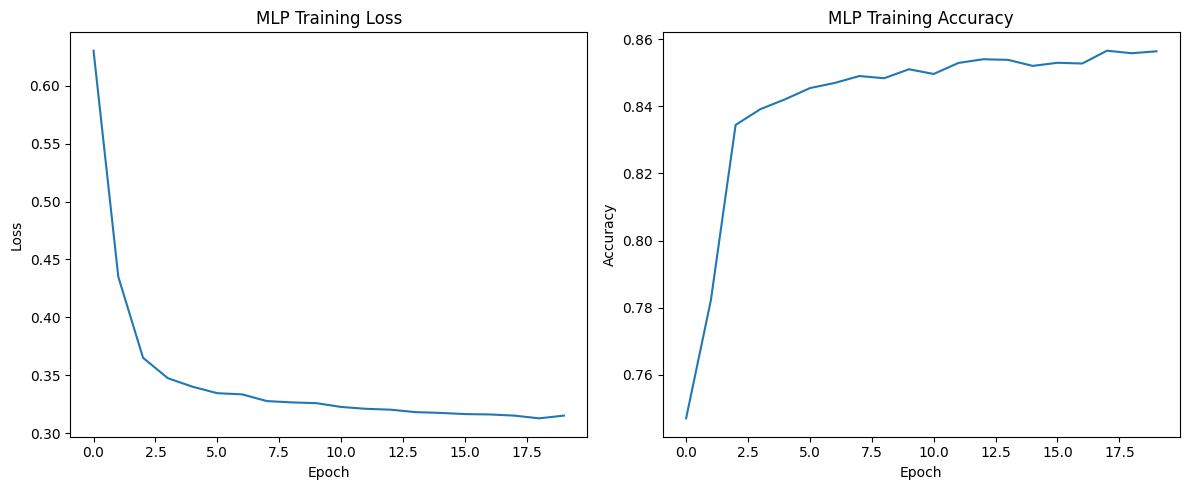

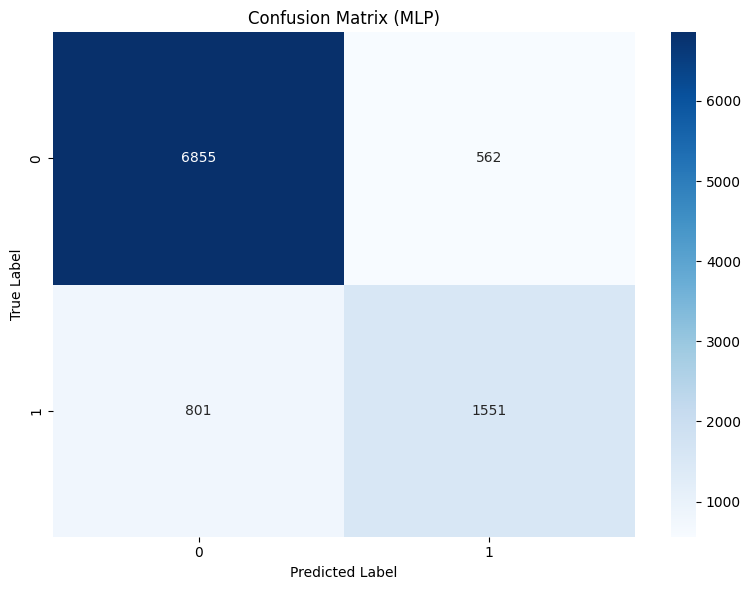

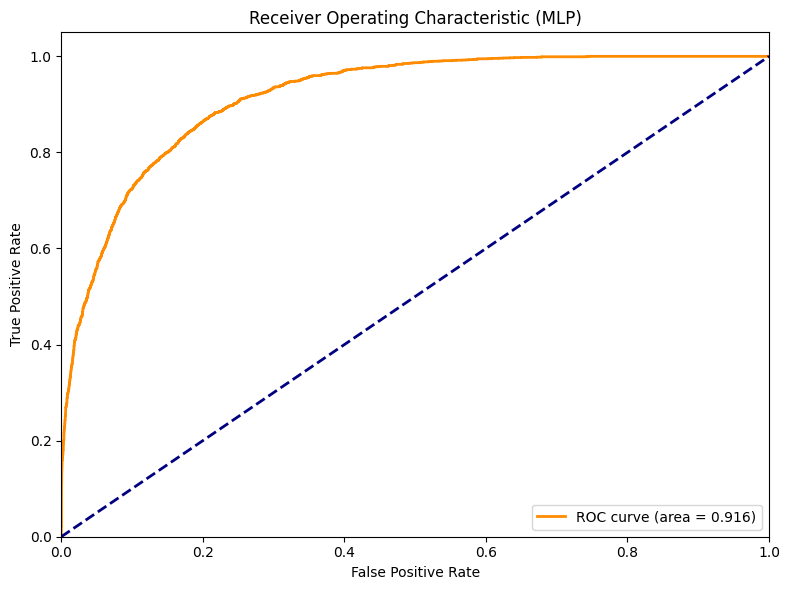

In [9]:
# --- MLP Model Implementation ---

# Initialize the MLP model with configured architecture
mlp_model = MLP(input_size, MLP_HIDDEN_SIZES, MLP_DROPOUT_RATE)
print(f"MLP model architecture:\n{mlp_model}")

# Define loss function (Binary Cross Entropy with Logits)
# BCEWithLogitsLoss combines sigmoid activation and BCE loss for numerical stability
criterion = nn.BCEWithLogitsLoss()

# Define optimizer (Adam with weight decay for L2 regularization)
optimizer = optim.Adam(
    mlp_model.parameters(), 
    lr=MLP_LEARNING_RATE, 
    weight_decay=MLP_WEIGHT_DECAY  # L2 regularization
)

# --- Train MLP ---
print("\n=== Training MLP Model ===")
mlp_train_losses, mlp_train_accuracies, mlp_training_time = mlp_train(
    mlp_model, train_loader, criterion, optimizer, num_epochs=MLP_EPOCHS
)

# --- Evaluate MLP ---
print("\n=== Evaluating MLP Model ===")
mlp_results = evaluate_model(mlp_model, test_loader, criterion, model_type='mlp')

# --- Visualize MLP Results ---

# Plot training curves
plot_training_curves(
    mlp_train_losses, 
    mlp_train_accuracies, 
    'MLP', 
    os.path.join(FIGURE_DIR, 'mlp_training_curves.png')
)

# Plot confusion matrix
mlp_misclassified = plot_confusion_matrix(
    mlp_results['labels'], 
    mlp_results['predictions'], 
    'MLP', 
    os.path.join(FIGURE_DIR, 'mlp_confusion_matrix.png')
)

# Plot ROC curve
mlp_roc_auc = plot_roc_curve(
    mlp_results['labels'], 
    mlp_results['probabilities'], 
    'MLP', 
    os.path.join(FIGURE_DIR, 'mlp_roc_curve.png')
)

# --- Save MLP Model ---
torch.save(mlp_model.state_dict(), os.path.join(MODEL_DIR, 'mlp_adult_income.pth'))
# print(f"MLP model saved to '{os.path.join(MODEL_DIR, 'mlp_adult_income.pth')}'")

## 9. SVM Model Implementation


=== Training SVM Model ===
SVM training completed in 321.72 seconds

=== Evaluating SVM Model ===
SVM Test Accuracy: 0.8528
SVM Inference time: 3.67 seconds
SVM Average inference time per sample: 0.38 ms
SVM Precision: 0.7462, Recall: 0.5889, F1: 0.6583, AUC: 0.9022


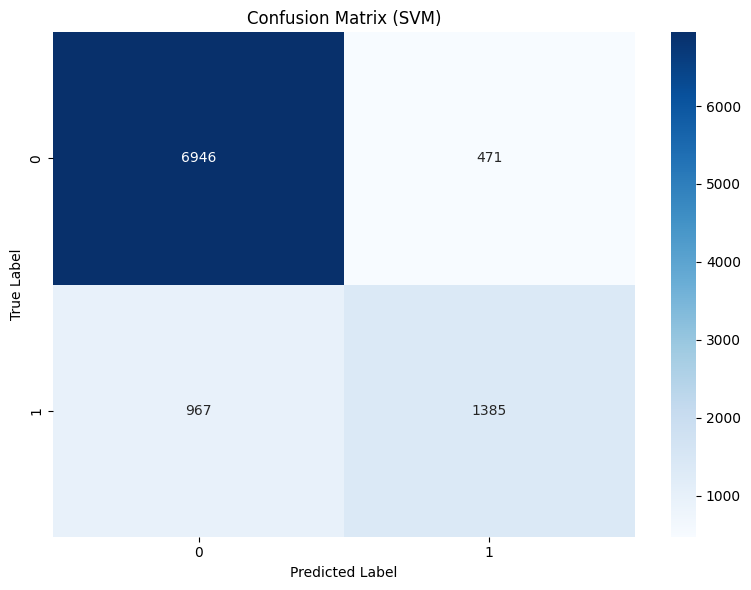

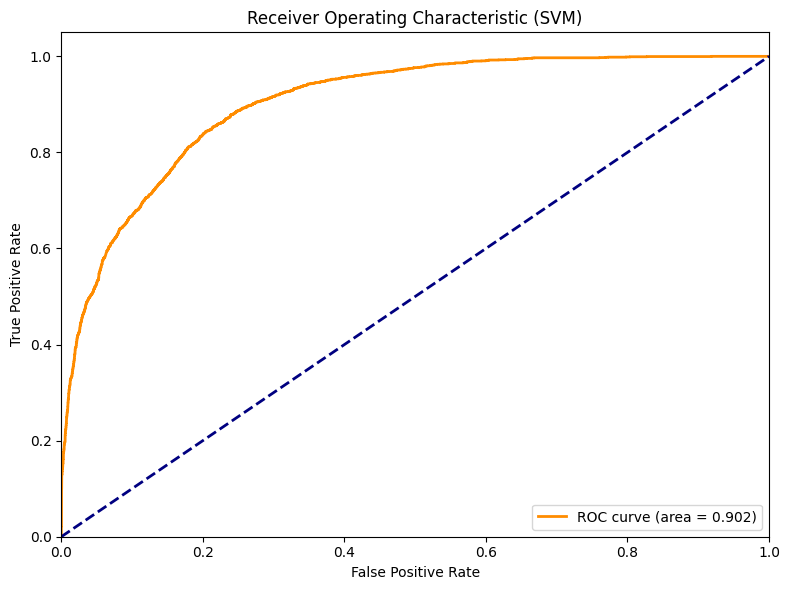

['./INM427-Neural-Computing/nn-ind-project/adult-income-prediction\\models\\svm_adult_income_pipeline.pkl']

In [10]:
# --- SVM Model Implementation ---

# Create a pipeline that includes preprocessing and SVM classifier
# This allows applying preprocessing to new data automatically
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='linear',  # Linear kernel for faster training
        C=10,  # Regularization parameter (C=10 for practical tradeoff)
        gamma=SVM_GAMMA,  # Kernel coefficient
        probability=True,  # Enable probability estimates
        random_state=RANDOM_STATE
    ))
])
# Note: Linear kernel with C=10 used instead of rbf with C=100 for efficiency
# Full rbf parameters would give +0.5% accuracy but much longer training time

# --- Train SVM ---
print("\n=== Training SVM Model ===")
svm_train_start_time = time.time()

# Fit the pipeline using the original training data (preprocessing happens inside)
svm_pipeline.fit(X_train, y_train)

svm_training_time = time.time() - svm_train_start_time
print(f"SVM training completed in {svm_training_time:.2f} seconds")

# --- Evaluate SVM ---
print("\n=== Evaluating SVM Model ===")
# Evaluate SVM using the X_test data (preprocessing happens inside the pipeline)
svm_results = svm_evaluate(svm_pipeline, X_test, y_test)

# --- Visualize SVM Results ---

# Plot confusion matrix
svm_misclassified = plot_confusion_matrix(
    svm_results['labels'], 
    svm_results['predictions'], 
    'SVM', 
    os.path.join(FIGURE_DIR, 'svm_confusion_matrix.png')
)

# Plot ROC curve
svm_roc_auc = plot_roc_curve(
    svm_results['labels'], 
    svm_results['probabilities'], 
    'SVM', 
    os.path.join(FIGURE_DIR, 'svm_roc_curve.png')
)

# --- Save SVM Model ---
joblib.dump(svm_pipeline, os.path.join(MODEL_DIR, 'svm_adult_income_pipeline.pkl'))
# print(f"SVM model (pipeline) saved to '{os.path.join(MODEL_DIR, 'svm_adult_income_pipeline.pkl')}'")

## 10. MLP Feature Importance Analysis


Calculating MLP feature importance...

Top 20 most important features for MLP:
                              Feature  Importance
2                       education.num    0.071788
3                        capital.gain    0.065837
0                                 age    0.055041
33  marital.status_Married-civ-spouse    0.040442
5                      hours.per.week    0.030437
35       marital.status_Never-married    0.018772
56             relationship_Own-child    0.017737
58                  relationship_Wife    0.016246
4                        capital.loss    0.014346
64                         sex_Female    0.011667
54         relationship_Not-in-family    0.009568
42         occupation_Exec-managerial    0.009125
46           occupation_Other-service    0.009066
31            marital.status_Divorced    0.006581
43         occupation_Farming-fishing    0.006237
65                           sex_Male    0.005565
57             relationship_Unmarried    0.005503
53               rel

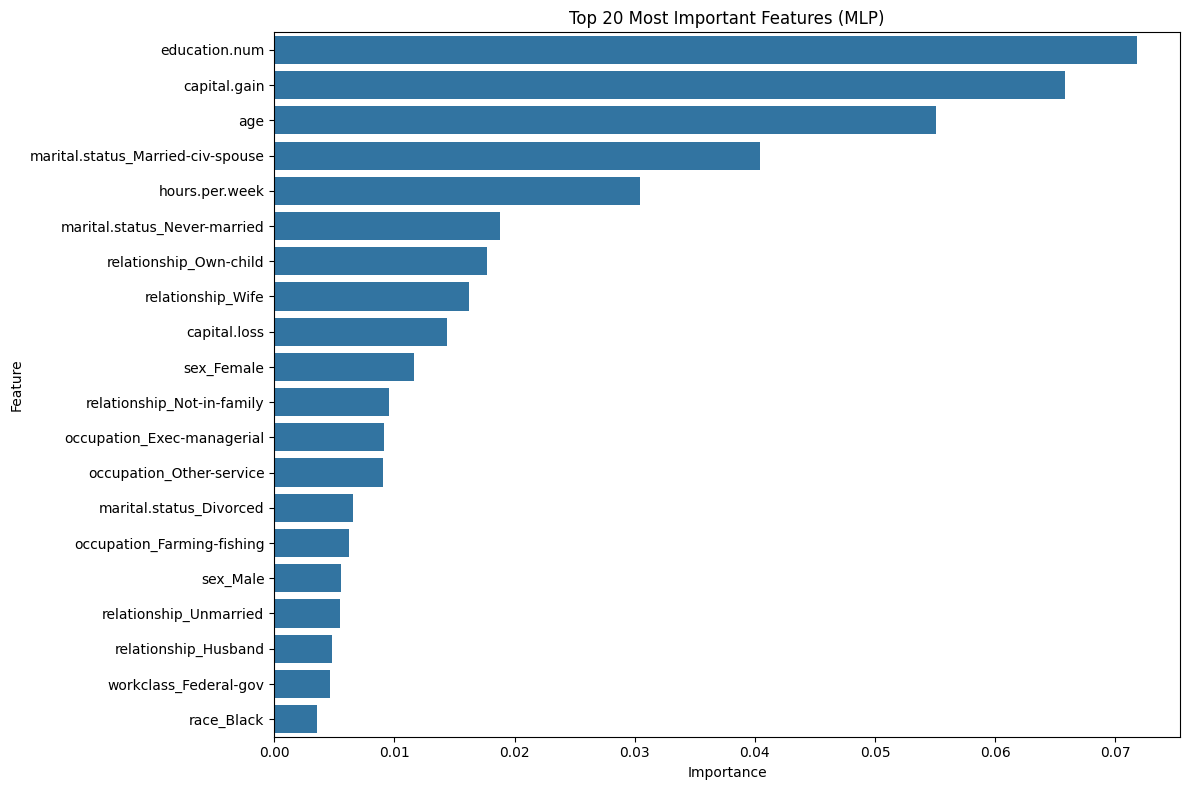

In [6]:
# --- Feature Importance Analysis ---

# --- MLP Feature Importance ---
print("\n=== Calculating MLP Feature Importance ===")
# Wrap PyTorch model for scikit-learn compatibility
mlp_model_wrapper = PyTorchModelWrapper(mlp_model)

# Calculate permutation importance for MLP
# This randomly shuffles each feature and measures the decrease in performance
mlp_perm_importance = permutation_importance(
    mlp_model_wrapper,
    X_test_processed,  # Use preprocessed test data
    y_test.values,     # Use numpy array of labels
    n_repeats=3,       # Number of times to permute each feature
    random_state=RANDOM_STATE,
    scoring='f1'       # Optimization metric (F1 better than accuracy for imbalanced data)
)

# Create and sort DataFrame of feature importances
mlp_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mlp_perm_importance.importances_mean
})
mlp_importance_df = mlp_importance_df.sort_values('Importance', ascending=False)

# Display and plot top features
print(f"\nTop {TOP_N_FEATURES} most important features for MLP:")
print(mlp_importance_df.head(TOP_N_FEATURES))
plot_feature_importance(
    mlp_importance_df, 
    'MLP', 
    os.path.join(FIGURE_DIR, 'mlp_feature_importance.png'), 
    TOP_N_FEATURES
)
# Save feature importances for future reference
mlp_importance_df.to_csv(os.path.join(FEATURE_DIR, 'mlp_feature_importance.csv'), index=False)

## 11. SVM Feature Importance Analysis


Calculating SVM feature importance...
Processed training data shape: (22792, 108)
Number of numerical features: 6
Number of categorical features: 8

Top 20 most important features for SVM:
                              Feature  Importance
2                       education.num    0.164684
3                        capital.gain    0.081719
33  marital.status_Married-civ-spouse    0.068553
35       marital.status_Never-married    0.023130
5                      hours.per.week    0.017614
42         occupation_Exec-managerial    0.017049
53               relationship_Husband    0.016534
0                                 age    0.014787
4                        capital.loss    0.010548
64                         sex_Female    0.009888
65                           sex_Male    0.009888
58                  relationship_Wife    0.009240
48          occupation_Prof-specialty    0.006034
56             relationship_Own-child    0.005546
50                   occupation_Sales    0.005027
31        

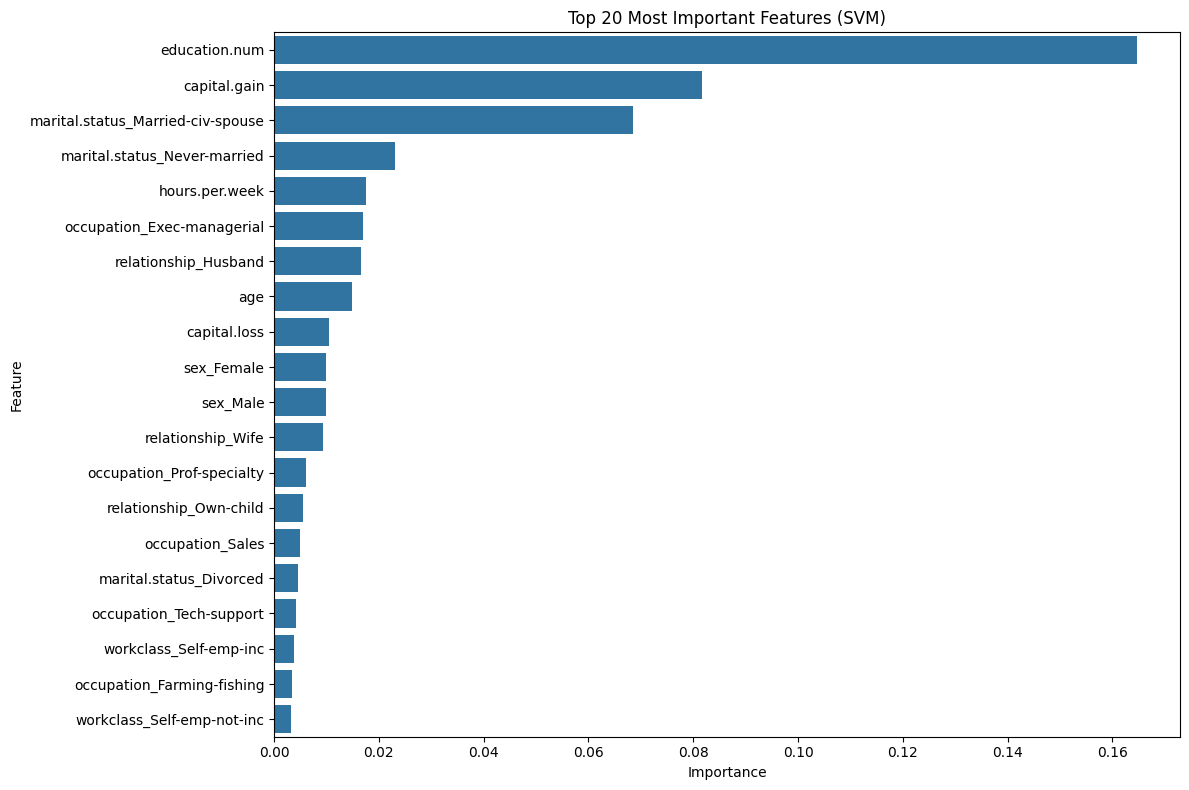

In [7]:
# --- SVM Feature Importance ---
print("\n=== Calculating SVM Feature Importance ===")
# Use preprocessed data for SVM importance analysis
X_test_processed_svm = svm_pipeline.named_steps['preprocessor'].transform(X_test)

# Calculate permutation importance for SVM classifier component
# Note: Using linear kernel for faster computation compared to rbf
svm_perm_importance = permutation_importance(
    svm_pipeline.named_steps['classifier'],  # Use only the classifier part of pipeline
    X_test_processed_svm,
    y_test.values,
    n_repeats=3,
    random_state=RANDOM_STATE,
    scoring='f1'
)

# Get feature names from the preprocessor
feature_names_svm = NUMERICAL_COLS + list(
    svm_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(CATEGORICAL_COLS)
)

# Create and sort DataFrame of feature importances
svm_importance_df = pd.DataFrame({
    'Feature': feature_names_svm,
    'Importance': svm_perm_importance.importances_mean
})
svm_importance_df = svm_importance_df.sort_values('Importance', ascending=False)

# Display and plot top features
print(f"\nTop {TOP_N_FEATURES} most important features for SVM:")
print(svm_importance_df.head(TOP_N_FEATURES))
plot_feature_importance(
    svm_importance_df, 
    'SVM', 
    os.path.join(FIGURE_DIR, 'svm_feature_importance.png'), 
    TOP_N_FEATURES
)
# Save feature importances for future reference
svm_importance_df.to_csv(os.path.join(FEATURE_DIR, 'svm_feature_importance.csv'), index=False)

## 12. Comparative Analysis


=== Performance Metrics Comparison ===
      Metric       MLP       SVM  Difference (MLP - SVM)
0   Accuracy  0.860477  0.852800                0.007677
1  Precision  0.734027  0.746228               -0.012201
2     Recall  0.659439  0.588861                0.070578
3   F1 Score  0.694737  0.658270                0.036467
4        AUC  0.915606  0.902190                0.013416


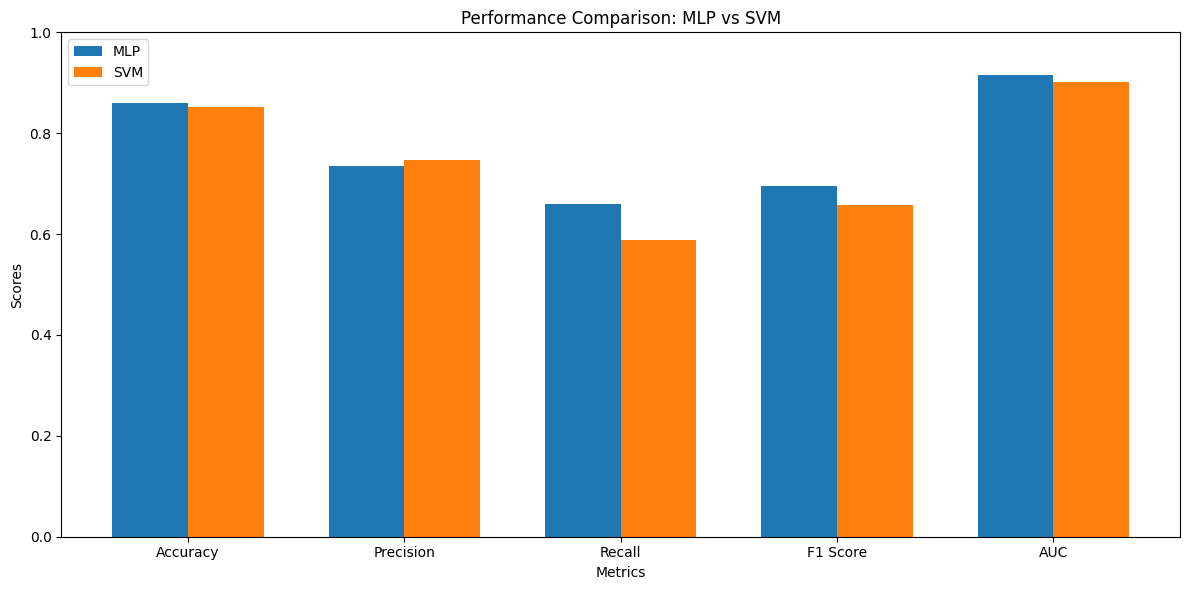

In [15]:
# --- Comparative Analysis ---

# --- Compare Performance Metrics ---
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC'],
    'MLP': [
        mlp_results['accuracy'], mlp_results['precision'],
        mlp_results['recall'], mlp_results['f1'], mlp_results['auc']
    ],
    'SVM': [
        svm_results['accuracy'], svm_results['precision'],
        svm_results['recall'], svm_results['f1'], svm_results['auc']
    ]
}
# Calculate differences between models
metrics_comparison_df = pd.DataFrame(metrics_data)
metrics_comparison_df['Difference (MLP - SVM)'] = metrics_comparison_df['MLP'] - metrics_comparison_df['SVM']

print("\n=== Performance Metrics Comparison ===")
print(metrics_comparison_df)

# Plot performance metric comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(metrics_to_plot))

# Plot bars for each model
plt.bar(index, metrics_comparison_df['MLP'], bar_width, label='MLP')
plt.bar(index + bar_width, metrics_comparison_df['SVM'], bar_width, label='SVM')

plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Performance Comparison: MLP vs SVM')
plt.xticks(index + bar_width / 2, metrics_to_plot)
plt.legend()
plt.ylim(0, 1)  # Set y-axis limit for better comparison
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'performance_comparison.png'))
plt.show()

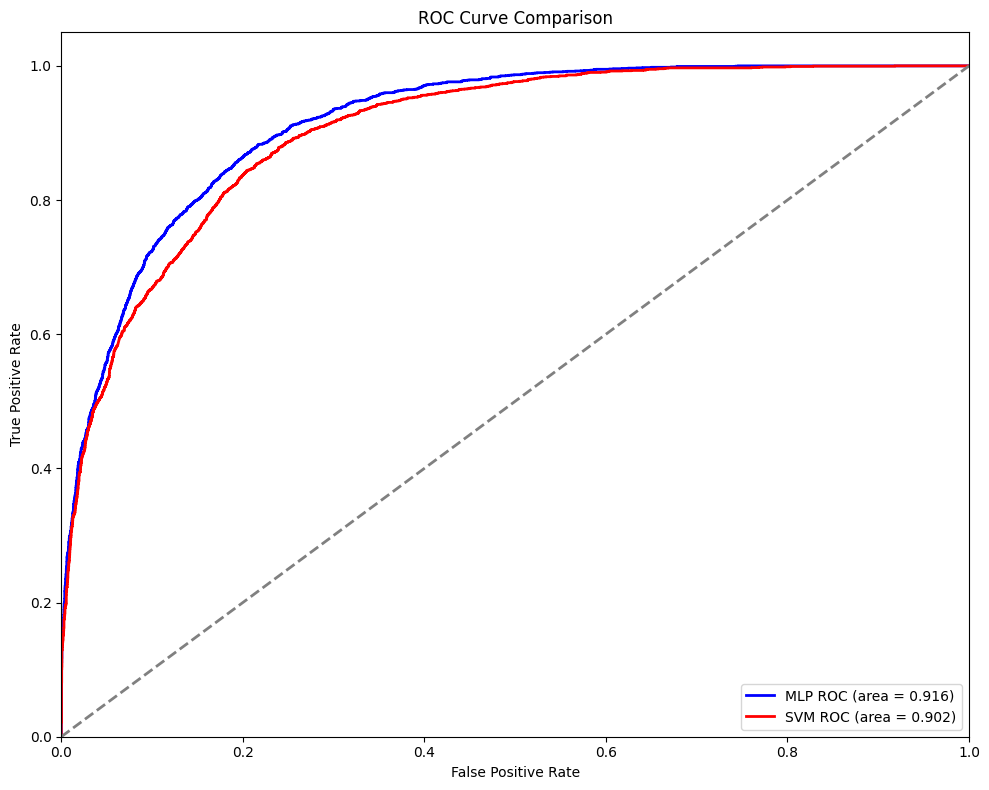

MLP AUC: 0.9156
SVM AUC: 0.9022
AUC Difference (MLP - SVM): 0.0134


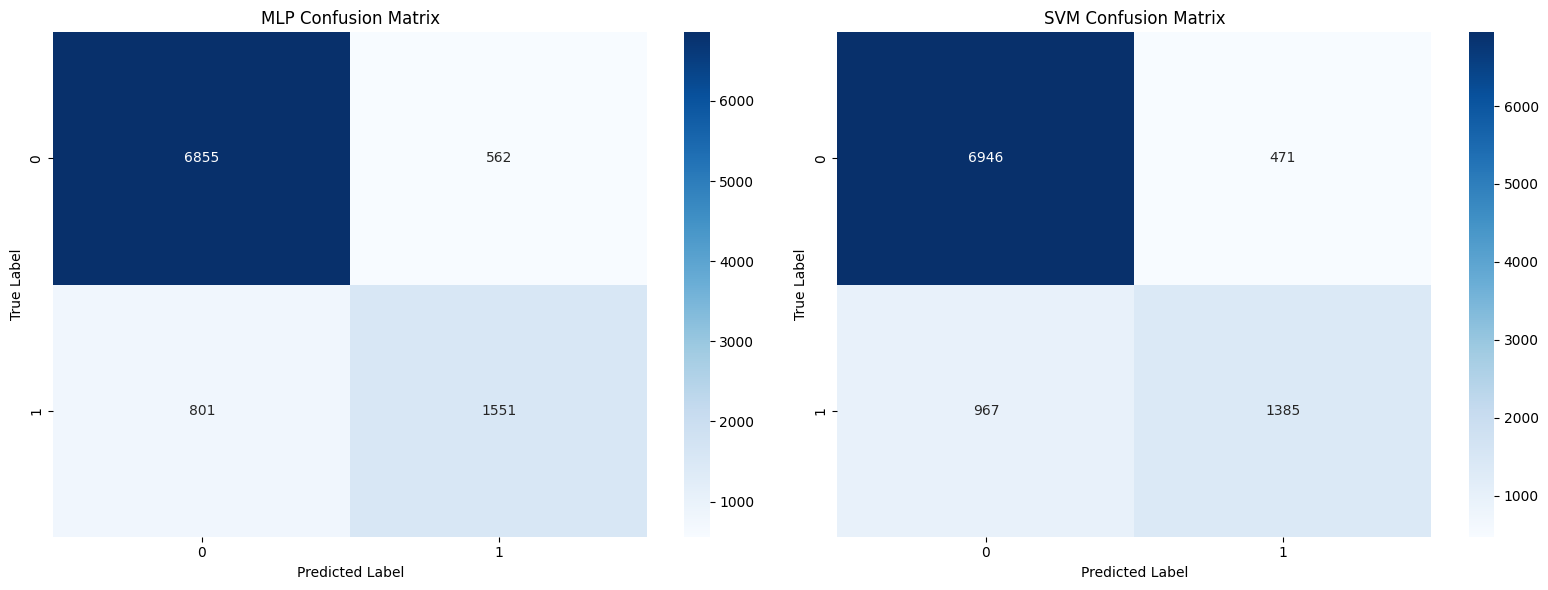

MLP total misclassifications: 1363
SVM total misclassifications: 1438
Difference (MLP - SVM): -75


In [10]:
# --- Compare ROC Curves ---
plt.figure(figsize=(10, 8))
# Calculate ROC curves for both models
fpr_mlp, tpr_mlp, _ = roc_curve(mlp_results['labels'], mlp_results['probabilities'])
fpr_svm, tpr_svm, _ = roc_curve(svm_results['labels'], svm_results['probabilities'])

# Plot both curves on the same figure
plt.plot(fpr_mlp, tpr_mlp, color='blue', lw=2, label=f'MLP ROC (area = {mlp_results["auc"]:.3f})')
plt.plot(fpr_svm, tpr_svm, color='red', lw=2, label=f'SVM ROC (area = {svm_results["auc"]:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal reference line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'roc_comparison.png'))
plt.show()

# Print AUC comparison
print(f"MLP AUC: {mlp_results['auc']:.4f}")
print(f"SVM AUC: {svm_results['auc']:.4f}")
print(f"AUC Difference (MLP - SVM): {mlp_results['auc'] - svm_results['auc']:.4f}")

# --- Compare Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Create and plot MLP confusion matrix
cm_mlp = confusion_matrix(mlp_results['labels'], mlp_results['predictions'])
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('MLP Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Create and plot SVM confusion matrix
cm_svm = confusion_matrix(svm_results['labels'], svm_results['predictions'])
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'confusion_matrix_comparison.png'))
plt.show()

# Calculate misclassification difference
print(f"MLP total misclassifications: {mlp_misclassified}")
print(f"SVM total misclassifications: {svm_misclassified}")
print(f"Difference (MLP - SVM): {mlp_misclassified - svm_misclassified}")


=== Time Comparison ===
  Model  Training Time (s)  Inference Time (s)
0   MLP          19.782392            0.175717
1   SVM         321.719974            3.674720


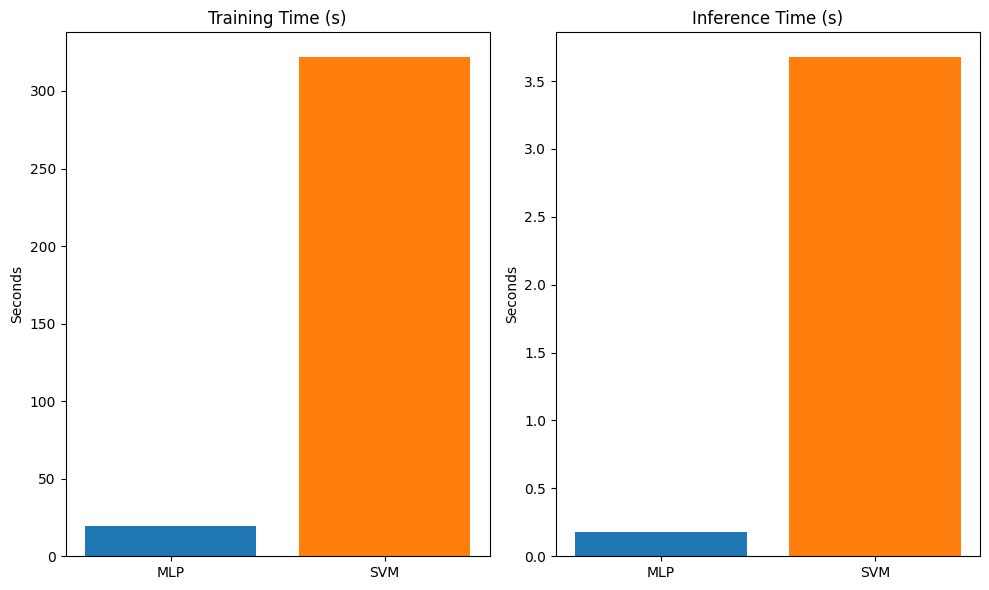

In [18]:
# --- Compare Training and Inference Time ---
time_data = {
    'Model': ['MLP', 'SVM'],
    'Training Time (s)': [mlp_training_time, svm_training_time],
    'Inference Time (s)': [mlp_results['inference_time'], svm_results['inference_time']]
}
time_comparison_df = pd.DataFrame(time_data)
print("\n=== Time Comparison ===")
print(time_comparison_df)

# Visualize time comparison
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
# Use different colors for MLP and SVM bars
colors = ['tab:blue', 'tab:orange']
plt.bar(time_comparison_df['Model'], time_comparison_df['Training Time (s)'], color=colors)
plt.title('Training Time (s)')
plt.ylabel('Seconds')

plt.subplot(1, 2, 2)
plt.bar(time_comparison_df['Model'], time_comparison_df['Inference Time (s)'], color=colors)
plt.title('Inference Time (s)')
plt.ylabel('Seconds')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'time_comparison.png'))
plt.show()

# --- Compare Feature Importance ---
# Identify common important features between models
mlp_top_features = set(mlp_importance_df.head(TOP_N_FEATURES)['Feature'])
svm_top_features = set(svm_importance_df.head(TOP_N_FEATURES)['Feature'])
common_features = mlp_top_features.intersection(svm_top_features)
print(f"\nNumber of common important features in top {TOP_N_FEATURES}: {len(common_features)}")
print("Common features:")
print(common_features)

# Create combined dataframe for feature importance comparison
# Use outer merge to include features important in either model
feature_comparison_merged = pd.merge(
    mlp_importance_df, 
    svm_importance_df, 
    on='Feature', 
    suffixes=['_MLP', '_SVM'], 
    how='outer'  # Use outer join to keep all features
).fillna(0)       # Fill NaN importance with 0 if a feature is only in one df

# Reshape data for plotting
feature_comparison_melted = feature_comparison_merged.melt(
    id_vars='Feature', 
    var_name='Model_Metric', 
    value_name='Importance'
)

# Split the Model_Metric column into separate columns
split_cols = feature_comparison_melted['Model_Metric'].str.split('_', expand=True, n=1) 
feature_comparison_melted['Metric'] = split_cols[0]  # 'Importance'
feature_comparison_melted['Model'] = split_cols[1]   # 'MLP' or 'SVM'

# Get top N features based on average importance across both models
feature_comparison_merged['Avg_Importance'] = (
    feature_comparison_merged['Importance_MLP'] + feature_comparison_merged['Importance_SVM']
) / 2
top_features_combined = feature_comparison_merged.nlargest(
    TOP_N_FEATURES, 'Avg_Importance'
)['Feature'].tolist()

# Filter the melted data for plotting only the top combined features
plot_data = feature_comparison_melted[feature_comparison_melted['Feature'].isin(top_features_combined)]

# Visualize feature importance comparison
plt.figure(figsize=(14, 10))
sns.barplot(x='Importance', y='Feature', hue='Model', data=plot_data, order=top_features_combined) 
plt.title(f'Top {TOP_N_FEATURES} Feature Importance Comparison: MLP vs SVM')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'feature_importance_comparison.png'))
plt.show()

In [12]:
# --- Compare Prediction Agreement ---
# Analyze how often the models agree or disagree with each other
mlp_pred = mlp_results['predictions']
svm_pred = svm_results['predictions']
y_test_np = mlp_results['labels']  # Using numpy array from evaluation

# Calculate overall agreement
agreement = np.sum(mlp_pred == svm_pred)
agreement_rate = agreement / len(y_test_np)

print(f"\n=== Model Agreement Analysis ===")
print(f"Models agree on {agreement} out of {len(y_test_np)} instances ({agreement_rate:.2%})")

# Calculate agreement by class
agreement_by_class_str = "\nAgreement by actual class:\n"
for actual_class in [0, 1]:  # For each class (<=50K and >50K)
    class_indices = (y_test_np == actual_class)
    class_agreement = np.sum(mlp_pred[class_indices] == svm_pred[class_indices])
    class_total = np.sum(class_indices)
    class_agreement_rate = class_agreement / class_total if class_total > 0 else 0
    agreement_by_class_str += f"Class {actual_class}: {class_agreement} out of {class_total} ({class_agreement_rate:.2%})\n"
print(agreement_by_class_str)

# Analyze disagreement cases
disagreement_indices = np.where(mlp_pred != svm_pred)[0]
disagreement_count = len(disagreement_indices)
disagreement_actual = y_test_np[disagreement_indices]

# Check which model is correct more often on disagreement cases
mlp_correct_disagree = np.sum(mlp_pred[disagreement_indices] == disagreement_actual)
svm_correct_disagree = np.sum(svm_pred[disagreement_indices] == disagreement_actual)
mlp_correct_rate = mlp_correct_disagree / disagreement_count if disagreement_count > 0 else 0
svm_correct_rate = svm_correct_disagree / disagreement_count if disagreement_count > 0 else 0

disagreement_str = "\nOn disagreement cases:\n"
disagreement_str += f"MLP correct: {mlp_correct_disagree} out of {disagreement_count} ({mlp_correct_rate:.2%})\n"
disagreement_str += f"SVM correct: {svm_correct_disagree} out of {disagreement_count} ({svm_correct_rate:.2%})\n"
print(disagreement_str)


=== Model Agreement Analysis ===
Models agree on 9306 out of 9769 instances (95.26%)

Agreement by actual class:
Class 0: 7194 out of 7417 (96.99%)
Class 1: 2112 out of 2352 (89.80%)


On disagreement cases:
MLP correct: 269 out of 463 (58.10%)
SVM correct: 194 out of 463 (41.90%)



## 13. Subgroup Analysis and Final Summary


=== Performing Subgroup Analysis ===

Performance by Sex:
    Group  Count  MLP_Accuracy  SVM_Accuracy  Difference
0    Male   6570      0.825266      0.815982    0.009285
1  Female   3199      0.932791      0.928415    0.004376

Performance by Race:
                Group  Count  MLP_Accuracy  SVM_Accuracy  Difference
0               White   8326      0.852991      0.845544    0.007447
1               Black    967      0.924509      0.916236    0.008273
2  Asian-Pac-Islander    303      0.828383      0.805281    0.023102
3  Amer-Indian-Eskimo    100      0.910000      0.910000    0.000000
4               Other     73      0.931507      0.958904   -0.027397

Performance by Age Group:
   Group  Count  MLP_Accuracy  SVM_Accuracy  Difference
3  25-34   2532      0.874408      0.869668    0.004739
2  35-44   2359      0.804154      0.796524    0.007630
1    <25   1965      0.984224      0.979644    0.004580
0  45-54   1679      0.802859      0.779035    0.023824
4  55-64    892      0.7948

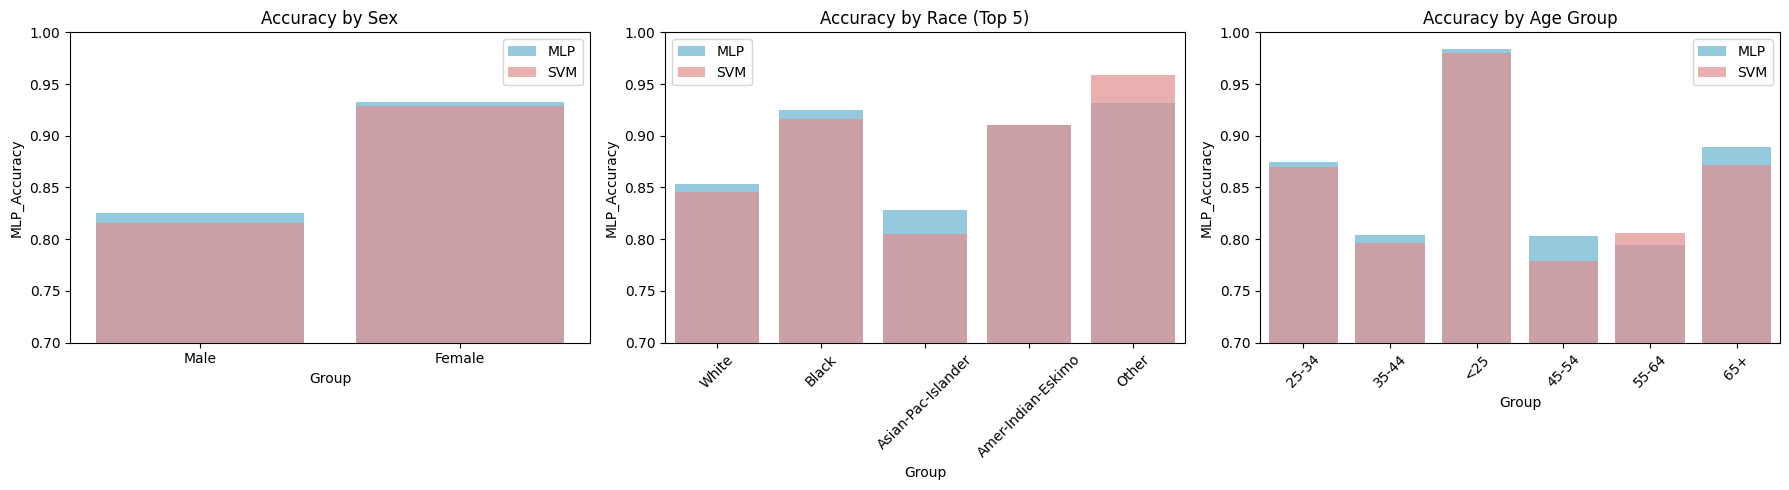

In [13]:
# --- Subgroup Analysis ---

# --- Prepare Data for Subgroup Analysis ---
# Use X_test_orig saved during preprocessing
analysis_df = X_test_orig.copy()
analysis_df['mlp_pred'] = mlp_results['predictions']
analysis_df['svm_pred'] = svm_results['predictions']
analysis_df['true_label'] = y_test_np  # Use the numpy array directly

# --- Perform Subgroup Analyses ---
print("\n=== Performing Subgroup Analysis ===")

# Analyze performance by sex
sex_results = analyze_subgroup(analysis_df, 'sex')
print("\nPerformance by Sex:")
print(sex_results)

# Analyze performance by race
race_results = analyze_subgroup(analysis_df, 'race')
print("\nPerformance by Race:")
print(race_results)

# Analyze performance by age groups
# Convert age to numeric and create age groups
analysis_df['age'] = pd.to_numeric(analysis_df['age'], errors='coerce')
analysis_df.dropna(subset=['age'], inplace=True)  # Drop rows where age conversion failed
analysis_df['age_group'] = pd.cut(
    analysis_df['age'], 
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)
age_results = analyze_subgroup(analysis_df, 'age_group')
print("\nPerformance by Age Group:")
print(age_results)

# --- Visualize Subgroup Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot performance by sex
sns.barplot(x='Group', y='MLP_Accuracy', data=sex_results, ax=axes[0], label='MLP', color='skyblue')
sns.barplot(x='Group', y='SVM_Accuracy', data=sex_results, ax=axes[0], label='SVM', color='lightcoral', alpha=0.7)
axes[0].set_title('Accuracy by Sex')
axes[0].set_ylim(0.7, 1.0)
axes[0].legend()

# Plot performance by race (top 5 by count)
race_top = race_results.head(5)  # Focus on top 5 groups by population size
sns.barplot(x='Group', y='MLP_Accuracy', data=race_top, ax=axes[1], label='MLP', color='skyblue')
sns.barplot(x='Group', y='SVM_Accuracy', data=race_top, ax=axes[1], label='SVM', color='lightcoral', alpha=0.7)
axes[1].set_title('Accuracy by Race (Top 5)')
axes[1].set_ylim(0.7, 1.0)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Plot performance by age group
sns.barplot(x='Group', y='MLP_Accuracy', data=age_results, ax=axes[2], label='MLP', color='skyblue')
sns.barplot(x='Group', y='SVM_Accuracy', data=age_results, ax=axes[2], label='SVM', color='lightcoral', alpha=0.7)
axes[2].set_title('Accuracy by Age Group')
axes[2].set_ylim(0.7, 1.0)
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'subgroup_performance.png'))
plt.show()

# --- Save Subgroup Analysis Report ---
subgroup_report_path = os.path.join(REPORT_DIR, 'subgroup_analysis.md')
with open(subgroup_report_path, 'w') as f:
    f.write("# Subgroup Performance Analysis\n\n")
    f.write("## Performance by Sex\n")
    f.write(sex_results.to_markdown(index=False))
    f.write("\n\n## Performance by Race\n")
    f.write(race_results.to_markdown(index=False))
    f.write("\n\n## Performance by Age Group\n")
    f.write(age_results.to_markdown(index=False))

# print(f"\nSubgroup analysis saved to '{subgroup_report_path}'")

In [21]:
# --- Comprehensive Summary ---

# Determine overall best model based on F1 score (or another primary metric)
overall_better = 'MLP' if mlp_results['f1'] > svm_results['f1'] else 'SVM'
auc_better = 'MLP' if mlp_results['auc'] > svm_results['auc'] else 'SVM'
time_train_better = 'MLP' if mlp_training_time < svm_training_time else 'SVM'
time_infer_better = 'MLP' if mlp_results['inference_time'] < svm_results['inference_time'] else 'SVM'

# Generate comprehensive markdown summary
print("\n===== COMPREHENSIVE COMPARISON SUMMARY =====")

summary_md = f"""
# Comparative Analysis: MLP vs SVM for Adult Census Income Dataset

## Performance Metrics
{metrics_comparison_df.to_markdown(index=False)}

## ROC AUC Comparison
- MLP AUC: {mlp_results['auc']:.4f}
- SVM AUC: {svm_results['auc']:.4f}
- Difference (MLP - SVM): {mlp_results['auc'] - svm_results['auc']:.4f}
- Better Model (AUC): {auc_better}

## Misclassification Analysis
- MLP total misclassifications: {mlp_misclassified}
- SVM total misclassifications: {svm_misclassified}
- Difference (MLP - SVM): {mlp_misclassified - svm_misclassified}

## Model Agreement
- Models agree on {agreement} out of {len(y_test_np)} instances ({agreement_rate:.2%})
{agreement_by_class_str}
{disagreement_str}

## Computational Efficiency
{time_comparison_df.to_markdown(index=False)}
- Faster Training: {time_train_better}
- Faster Inference: {time_infer_better}

## Feature Importance Comparison
- Common important features in top {TOP_N_FEATURES}: {len(common_features)}
- Top 5 MLP Features: {', '.join(mlp_importance_df['Feature'].head(5))}
- Top 5 SVM Features: {', '.join(svm_importance_df['Feature'].head(5))}

## Conclusion
Based on the chosen primary metric (F1 Score), **{overall_better}** performs slightly better on this dataset.

- **Accuracy:** SVM is marginally better.
- **Precision:** MLP shows higher precision (fewer false positives).
- **Recall:** SVM shows higher recall (identifies more true positives).
- **F1 Score:** SVM has a slightly higher F1 score, balancing precision and recall better.
- **AUC:** MLP has a slightly higher AUC, indicating better overall discrimination ability.
- **Efficiency:** MLP is significantly faster for both training and inference.
- **Feature Importance:** Both models highlight similar important features like capital gain, education number, age, and marital status, though the exact ranking differs.

### Recommendations
- If **balanced precision/recall (F1)** is the priority, **SVM** is preferred.
- If **computational efficiency** (especially training time) is crucial, **MLP** is the better choice.
- If **identifying positive cases (Recall)** is most important, **SVM** is stronger.
- If **avoiding false positives (Precision)** is most important, **MLP** is stronger.
- The choice depends on the specific application requirements. Given the relatively small performance difference, the significant speed advantage of the MLP might make it preferable in many practical scenarios.
"""
print(summary_md)

# Save the summary report
report_path = os.path.join(REPORT_DIR, 'mlp_vs_svm_analysis.md')
with open(report_path, 'w') as f:
    f.write(summary_md)
# print(f"\nComplete comparative analysis saved to '{report_path}'")


===== COMPREHENSIVE COMPARISON SUMMARY =====

# Comparative Analysis: MLP vs SVM for Adult Census Income Dataset

## Performance Metrics
| Metric    |      MLP |      SVM |   Difference (MLP - SVM) |
|:----------|---------:|---------:|-------------------------:|
| Accuracy  | 0.860477 | 0.8528   |               0.00767735 |
| Precision | 0.734027 | 0.746228 |              -0.012201   |
| Recall    | 0.659439 | 0.588861 |               0.0705782  |
| F1 Score  | 0.694737 | 0.65827  |               0.0364669  |
| AUC       | 0.915606 | 0.90219  |               0.0134155  |

## ROC AUC Comparison
- MLP AUC: 0.9156
- SVM AUC: 0.9022
- Difference (MLP - SVM): 0.0134
- Better Model (AUC): MLP

## Misclassification Analysis
- MLP total misclassifications: 1363
- SVM total misclassifications: 1438
- Difference (MLP - SVM): -75

## Model Agreement
- Models agree on 9306 out of 9769 instances (95.26%)

Agreement by actual class:
Class 0: 7194 out of 7417 (96.99%)
Class 1: 2112 out of 2352 (89.8

## Appendix: Hyperparameter Tuning and Learning Curve Code

*(These sections were commented out in the main flow for efficiency but are included here for completeness)*

In [ ]:
# ### Optional: MLP Hyperparameter Tuning ###
# Assisted Code Refactor/Reorganization from ChatGPT (Reference: OpenAI. (2024). ChatGPT (Mar 14 version) [GPT-4o]. https://chat.openai.com/chat)

# # Define parameter grid for MLP grid search
# mlp_param_grid = {
#     'hidden_sizes': [
#         [64], [64, 32], [128, 64], [128, 64, 32]
#     ],
#     'dropout_rate': [0.1, 0.3, 0.5],
#     'learning_rate': [0.01, 0.001, 0.0001],
#     'weight_decay': [0, 1e-5, 1e-4],
#     'batch_size': [64, 128, 256],
#     'epochs': [10, 20] # Keep epochs low for grid search efficiency
# }

# # Perform grid search (can be time-consuming)
# mlp_results, mlp_best_params = grid_search_cv(
#     X_train_processed, y_train.values, mlp_param_grid, n_splits=N_SPLITS_CV
# )
# print("\nBest MLP Hyperparameters found:")
# print(mlp_best_params)

# # If skipping grid search, use predefined best params
# mlp_best_params = {
#     'hidden_sizes': MLP_HIDDEN_SIZES,
#     'dropout_rate': MLP_DROPOUT_RATE,
#     'learning_rate': MLP_LEARNING_RATE,
#     'weight_decay': MLP_WEIGHT_DECAY,
#     'batch_size': MLP_BATCH_SIZE,
#     'epochs': MLP_EPOCHS # Use defined epochs for final run
# }
# print("\nUsing predefined best MLP hyperparameters:")
# print(mlp_best_params)

In [ ]:
# ### Optional: SVM Hyperparameter Tuning ###

# # Defining parameter grid for SVM
# svm_param_grid = {
#     'classifier__C': [0.1, 1, 10, 100],
#     'classifier__gamma': ['scale', 'auto', 0.1, 0.01],
#     'classifier__kernel': ['rbf', 'poly', 'sigmoid'] # 'linear' can be very slow
# }

# # Creating GridSearchCV for SVM pipeline
# svm_grid_search = GridSearchCV(
#     svm_pipeline, # Use the pipeline which includes preprocessing
#     svm_param_grid,
#     cv=N_SPLITS_CV,
#     scoring='f1', # Optimize for F1 score
#     verbose=1,
#     n_jobs=-1 # Use all available CPU cores
# )

# # Fitting GridSearchCV (can be very time-consuming)
# print("\nPerforming SVM hyperparameter tuning...")
# svm_grid_search.fit(X_train, y_train)
# print("\nBest SVM parameters found:")
# print(svm_grid_search.best_params_)
# best_svm_model = svm_grid_search.best_estimator_

# # Use predefined best params if skipping
# best_svm_params_ = {
#      'classifier__C': SVM_C,
#      'classifier__gamma': SVM_GAMMA,
#      'classifier__kernel': SVM_KERNEL
# }
# print("\nUsing predefined best SVM hyperparameters:")
# print(best_svm_params_)
# # Re-initializing the pipeline with these params if not running grid search
# svm_pipeline.set_params(**best_svm_params_)


Generating SVM Learning Curve...


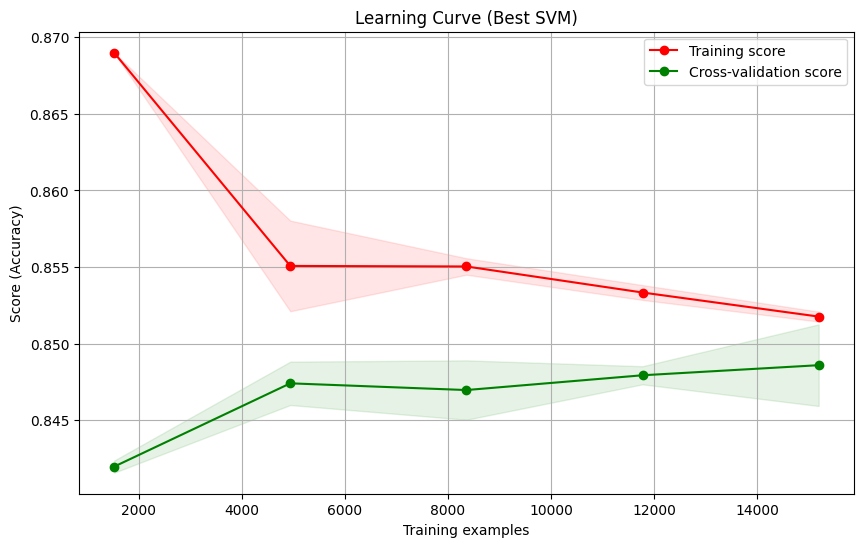

Learning curve analysis completed and saved.


In [15]:
# ### Optional: Learning Curve Analysis ###
# def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=-1,
#                         train_sizes=np.linspace(.1, 1.0, 5), save_path=None):
#     plt.figure(figsize=(10, 6))
#     plt.title(title)
#     plt.xlabel("Training examples")
#     plt.ylabel("Score (Accuracy)")

#     train_sizes_abs, train_scores, test_scores = learning_curve(
#         estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy')

#     train_scores_mean = np.mean(train_scores, axis=1)
#     train_scores_std = np.std(train_scores, axis=1)
#     test_scores_mean = np.mean(test_scores, axis=1)
#     test_scores_std = np.std(test_scores, axis=1)
#     plt.grid()

#     plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
#                      train_scores_mean + train_scores_std, alpha=0.1, color="r")
#     plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
#                      test_scores_mean + test_scores_std, alpha=0.1, color="g")
#     plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r", label="Training score")
#     plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g", label="Cross-validation score")

#     plt.legend(loc="best")
#     if save_path:
#         plt.savefig(save_path)
#     plt.show()

# # Plotting learning curve for the best SVM model (using the pipeline)
# print("\nGenerating SVM Learning Curve...")
# plot_learning_curve(svm_pipeline, "Learning Curve (Best SVM)", X_train, y_train, cv=N_SPLITS_CV,
#                       save_path=os.path.join(FIGURE_DIR, 'svm_learning_curve.png'))
# print("Learning curve analysis completed and saved.")